In [1]:
!pip install python-chess tensorflow numpy matplotlib
import chess
import chess.svg
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import random
import matplotlib.pyplot as plt
from collections import deque

print("TensorFlow Version:", tf.__version__)

     ---------------------------------------- 0.0/6.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/6.1 MB ? eta -:--:--
     - -------------------------------------- 0.3/6.1 MB ? eta -:--:--
     - -------------------------------------- 0.3/6.1 MB ? eta -:--:--
     --- ------------------------------------ 0.5/6.1 MB 670.4 kB/s eta 0:00:09
     ----- ---------------------------------- 0.8/6.1 MB 817.9 kB/s eta 0:00:07
     ------ --------------------------------- 1.0/6.1 MB 915.5 kB/s eta 0:00:06
     -------- ------------------------------- 1.3/6.1 MB 972.7 kB/s eta 0:00:05
     ---------- ----------------------------- 1.6/6.1 MB 1.1 MB/s eta 0:00:05
     ------------- -------------------------- 2.1/6.1 MB 1.2 MB/s eta 0:00:04
     --------------- ------------------------ 2.4/6.1 MB 1.2 MB/s eta 0:00:04
     ----------------- ---------------------- 2.6/6.1 MB 1.3 MB/s eta 0:00:03
     -------------------- ------------------- 3.1/6.1 MB 1.4 MB/s eta 0:00:03
     -

  DEPRECATION: Building 'chess' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'chess'. Discussion can be found at https://github.com/pypa/pip/issues/6334
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
google-api-core 2.30.0 requires protobuf<7.0.0,>=4.25.8, but you have protobuf 7.35.1 which is incompatible.
googleapis-common-protos 1.73.0 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.

TensorFlow Version: 2.21.0


In [2]:
PIECE_TO_INDEX = {
    chess.PAWN: 0, chess.KNIGHT: 1, chess.BISHOP: 2,
    chess.ROOK: 3, chess.QUEEN: 4, chess.KING: 5
}

def board_to_matrix(board):
    matrix = np.zeros((8, 8, 12), dtype=np.float32)
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece is not None:
            row = 7 - (square // 8)
            col = square % 8
            piece_idx = PIECE_TO_INDEX[piece.piece_type]
            if piece.color == chess.BLACK:
                piece_idx += 6
            matrix[row, col, piece_idx] = 1.0
    return matrix

In [4]:
class ChessDQN(tf.keras.Model):
    def __init__(self):
        super(ChessDQN, self).__init__()
        self.conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(8, 8, 12))
        self.conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(256, activation='relu')
        self.q_values = layers.Dense(1, activation='linear')

    def call(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.flatten(x)
        x = self.dense1(x)
        return self.q_values(x)

In [5]:
def select_best_move(model, board, epsilon):
    legal_moves = list(board.legal_moves)
    if not legal_moves:
        return None

    if random.random() < epsilon:
        return random.choice(legal_moves)

    best_move = None
    max_q = -float('inf')

    for move in legal_moves:
        board.push(move)
        state_matrix = np.expand_dims(board_to_matrix(board), axis=0)
        q_val = model(state_matrix).numpy()[0][0]
        board.pop()

        if q_val > max_q:
            max_q = q_val
            best_move = move

    return best_move if best_move else random.choice(legal_moves)

def calculate_reward(board):
    if board.is_game_over():
        outcome = board.outcome()
        if outcome.winner == chess.WHITE:
            return 100.0
        elif outcome.winner == chess.BLACK:
            return -100.0
        return 0.0
    return 0.1

In [30]:
epsilon = 1.0
epsilon_decay = 0.99
min_epsilon = 0.05
num_episodes = 20

model = ChessDQN()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
episode_rewards = []

for episode in range(num_episodes):
    board = chess.Board()
    total_reward = 0

    while not board.is_game_over():
        move = select_best_move(model, board, epsilon)
        if move is None:
            break
        board.push(move)
        reward = calculate_reward(board)
        total_reward += reward

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)
    if (episode + 1) % 5 == 0:
        print(f"Episode {episode+1}/{num_episodes} | Total Reward: {total_reward:.2f} | Epsilon: {epsilon:.2f}")

Episode 5/20 | Total Reward: 124.20 | Epsilon: 0.95
Episode 10/20 | Total Reward: 55.00 | Epsilon: 0.90
Episode 15/20 | Total Reward: 36.00 | Epsilon: 0.86
Episode 20/20 | Total Reward: 34.50 | Epsilon: 0.82


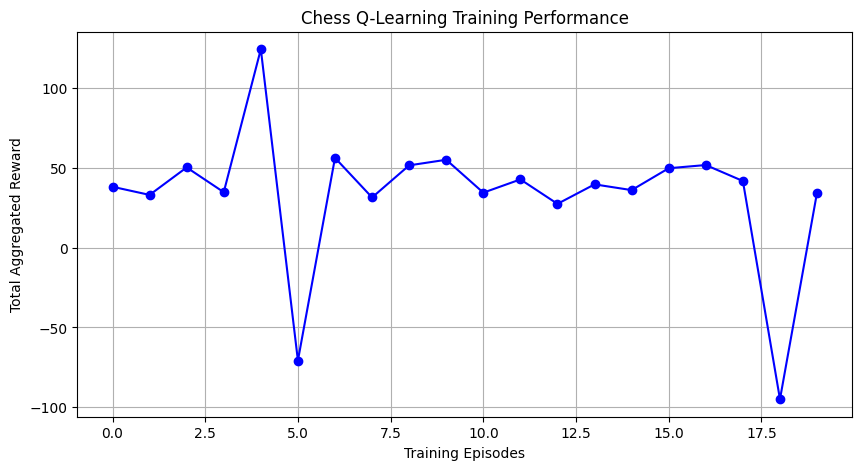

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, marker='o', color='b', linestyle='-')
plt.title('Chess Q-Learning Training Performance')
plt.xlabel('Training Episodes')
plt.ylabel('Total Aggregated Reward')
plt.grid(True)
plt.show()

In [27]:
import tkinter as tk
from tkinter import messagebox
import chess
import numpy as np

class InteractiveChessGUI:

    def __init__(self, root, ai_model):
        self.root = root
        self.model = ai_model
        self.board = chess.Board()

        self.square_size = 70
        self.canvas = tk.Canvas(root, width=8 * self.square_size, height=8 * self.square_size)
        self.canvas.pack()

        self.selected_square = None
        self.canvas.bind("<Button-1>", self.on_square_click)

        self.colors = ["#eeeed2", "#769656"]
        self.draw_board()

    def draw_board(self):
        self.canvas.delete("all")
        for row in range(8):
            for col in range(8):
                color = self.colors[(row + col) % 2]
                x1 = col * self.square_size
                y1 = row * self.square_size
                x2 = x1 + self.square_size
                y2 = y1 + self.square_size
                self.canvas.create_rectangle(x1, y1, x2, y2, fill=color, outline="")

        for square in chess.SQUARES:
            piece = self.board.piece_at(square)
            if piece is not None:
                col = square % 8
                row = 7 - (square // 8)
                x = col * self.square_size + (self.square_size / 2)
                y = row * self.square_size + (self.square_size / 2)

                text_color = "black" if piece.color == chess.BLACK else "white"
                outline_color = "white" if piece.color == chess.BLACK else "black"

                self.canvas.create_text(
                    x, y, text=piece.unicode_symbol(),
                    font=("Helvetica", 36), fill=outline_color
                )
                self.canvas.create_text(
                    x, y, text=piece.unicode_symbol(),
                    font=("Helvetica", 32), fill=text_color
                )

    def on_square_click(self, event):
        col = event.x // self.square_size
        row = 7 - (event.y // self.square_size)
        clicked_square = chess.square(col, row)

        if self.selected_square is None:
            if self.board.piece_at(clicked_square) and self.board.piece_at(clicked_square).color == chess.WHITE:
                self.selected_square = clicked_square
                x1 = col * self.square_size
                y1 = (7 - row) * self.square_size
                self.canvas.create_rectangle(x1, y1, x1+self.square_size, y1+self.square_size, outline="red", width=3)
        else:
            move = chess.Move(self.selected_square, clicked_square)

            # Check for pawn promotions
            if move in self.board.legal_moves or chess.Move(self.selected_square, clicked_square, chess.QUEEN) in self.board.legal_moves:
                if chess.Move(self.selected_square, clicked_square, chess.QUEEN) in self.board.legal_moves:
                    move = chess.Move(self.selected_square, clicked_square, chess.QUEEN)

                self.board.push(move)
                self.selected_square = None
                self.draw_board()

                if not self.check_game_state():
                    self.root.after(500, self.trigger_ai_move)
            else:
                self.selected_square = None
                self.draw_board()

    def trigger_ai_move(self):
        legal_moves = list(self.board.legal_moves)
        if not legal_moves:
            return

        best_move = None
        max_q = -float('inf')

        for move in legal_moves:
            self.board.push(move)
            state_matrix = np.expand_dims(board_to_matrix(self.board), axis=0)
            q_val = self.model(state_matrix).numpy()[0][0]
            self.board.pop()

            if q_val > max_q:
                max_q = q_val
                best_move = move

        ai_choice = best_move if best_move else random.choice(legal_moves)
        self.board.push(ai_choice)
        self.draw_board()
        self.check_game_state()

    def check_game_state(self):
        if self.board.is_game_over():
            outcome = self.board.outcome().termination.name
            messagebox.showinfo("Game Over", f"Match terminated via: {outcome}")
            return True
        return False

def launch(trained_model):
    window = tk.Tk()
    window.title("Interactive Chess Engine")
    gui = InteractiveChessGUI(window, trained_model)
    window.mainloop()

In [32]:
launch(model)